# CW2 reference solution — `HighHealthNeeds`

**Instructor-facing.** This notebook walks the improvement ladder that CW2 asks
students to discover, measuring every rung so that the payoff for each change is
visible and quantified. It serves three purposes:

1. **Validation** — evidence that the dataset is fit for purpose. If a rung stopped
   paying off, the assignment built on it would be unsound. (`validate_ml_ladder.py`
   asserts the same properties non-interactively.)
2. **A marking reference** — a worked example of the depth a strong submission can
   reach, and where the genuinely hard findings are.
3. **A benchmark** — the closing numbers are the "here is what I got, try to beat
   this" target.

The ladder, in order: crude baseline → data quality → scaling → class imbalance →
hyperparameter tuning → validation method → a more expressive model → decision
cost and the two stakeholders → leakage → overfitting → distribution shift.

Everything is scored from `model.predict()` alone: accuracy, precision, recall, F1,
balanced accuracy and the confusion matrix, plus each stakeholder's cost per person.
No predicted probabilities and no decision thresholds appear anywhere.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score, confusion_matrix)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from costs import (COST_EMPLOYER, COST_PUBLIC_HEALTH, COST_MATRICES,
                   cost_per_person, confusion_counts)

RANDOM_STATE = 42
TARGET = 'HighHealthNeeds'

# Chart styling: recessive grid and axes, ink for text, colour reserved for data.
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
INK, MUTED = '#0b0b0b', '#898781'
plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': '#52514e', 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'figure.dpi': 110, 'legend.frameon': False,
})

ladder = []   # every rung's headline numbers, collected for the summary table

### Shared helpers

`encode` is shared with the starter notebook. `naive_clean` reproduces what the
starter does; `careful_clean` is the version a student should arrive at.

In [2]:
ORDINAL_SCALES = {
    'Stress Level': ['Low', 'Medium', 'High'],
    'Physical Activity Level': ['Sedentary', 'Lightly Active', 'Moderately Active', 'Very Active'],
    'Sleep Quality': ['Poor', 'Fair', 'Good', 'Excellent'],
    'Health Issues': ['No Issues', 'Mild', 'Moderate', 'Severe'],
    'Smoking Status': ['Never', 'Former', 'Vaper', 'Light Smoker', 'Heavy Smoker'],
    'Alcohol Level': ['Non-Drinker', 'Light', 'Moderate', 'Heavy'],
    'SelfRatedHealth': ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'],
}

def encode(df, keep_self_rated_health=False):
    d = df.copy()
    for column, order in ORDINAL_SCALES.items():
        if column == 'SelfRatedHealth' and not keep_self_rated_health:
            continue
        d[column] = d[column].map({value: i for i, value in enumerate(order)})
    if not keep_self_rated_health:
        d = d.drop(columns=['SelfRatedHealth'])
    d = pd.get_dummies(d, columns=['Country', 'Gender'], drop_first=True)
    y = d.pop(TARGET)
    return d.drop(columns=['ID']).astype(float), y

def naive_clean(df):
    """The starter notebook's approach: drop duplicates, drop any incomplete row."""
    return df.drop_duplicates().dropna()

def careful_clean(df):
    """Repair the anomalies instead of discarding the rows; impute instead of dropping."""
    d = df.drop_duplicates().copy()
    age_typo = d['Age'] > 100                     # a doubled digit: 34 -> 344
    d.loc[age_typo, 'Age'] = d.loc[age_typo, 'Age'].map(lambda v: int(str(int(v))[:-1]))
    bmi_typo = d['BMI'] > 60                      # a missed decimal point: 24.5 -> 245
    d.loc[bmi_typo, 'BMI'] = (d.loc[bmi_typo, 'BMI'] / 10).round(1)
    for column in d.columns:
        if d[column].isna().any():
            fill = d[column].median() if d[column].dtype != object else d[column].mode()[0]
            d[column] = d[column].fillna(fill)
    return d

def metrics(y_true, y_pred):
    out = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'cost_agency': cost_per_person(y_true, y_pred, COST_PUBLIC_HEALTH),
        'cost_employer': cost_per_person(y_true, y_pred, COST_EMPLOYER),
    }
    return out

def record(stage, label, m):
    ladder.append({'stage': stage, 'model': label, **m})
    print(f'{label:<38} acc={m["accuracy"]:.3f}  rec+={m["recall"]:.3f}  '
          f'F1={m["f1"]:.4f}  '
          f'costA={m["cost_agency"]:+7.1f}  costB={m["cost_employer"]:+7.1f}')
    return m

dev_raw = pd.read_csv('coffee_health_v3_dev.csv')
test_raw = pd.read_csv('coffee_health_v3_test.csv')
print(f'development {len(dev_raw)} rows   held-out test {len(test_raw)} rows')

development 10040 rows   held-out test 3060 rows


---
## Stage 0 — reproducing the starter baseline

Before improving anything, establish what the starting point actually is. The number
that matters is not the accuracy: it is the confusion matrix underneath it.

In [3]:
dev_naive = naive_clean(dev_raw)
X_naive, y_naive = encode(dev_naive, keep_self_rated_health=True)   # starter keeps everything
Xtr0, Xva0, ytr0, yva0 = train_test_split(X_naive, y_naive, test_size=0.2,
                                          random_state=RANDOM_STATE)

majority_accuracy = 1 - yva0.mean()
print(f'rows after naive cleaning: {len(dev_naive)} of {len(dev_raw)} '
      f'({len(dev_naive)/len(dev_raw):.0%})')
print(f'predict-everyone-negative accuracy: {majority_accuracy:.3f}\n')

for label, model in [('LogisticRegression() default', LogisticRegression()),
                     ('KNeighborsClassifier() default', KNeighborsClassifier())]:
    model.fit(Xtr0, ytr0)
    pred = model.predict(Xva0)
    m = record('0 starter', label, metrics(yva0, pred))
    counts = confusion_counts(yva0, pred)
    print(f'{"":38}   TN={counts["TN"]} FP={counts["FP"]} FN={counts["FN"]} TP={counts["TP"]}')

rows after naive cleaning: 7385 of 10040 (74%)
predict-everyone-negative accuracy: 0.802

LogisticRegression() default           acc=0.797  rec+=0.014  F1=0.0260  costA= +283.1  costB= +156.3
                                         TN=1173 FP=11 FN=289 TP=4


KNeighborsClassifier() default         acc=0.766  rec+=0.058  F1=0.0895  costA= +271.2  costB= +169.5
                                         TN=1114 FP=70 FN=276 TP=17


**The finding.** Logistic regression reports around 80% accuracy and identifies *nobody*.
It is exactly as accurate as a single line of code that predicts "no" for every person,
and it would leave every single high-needs case without an invitation. KNN scores
*below* the majority-class baseline while finding a handful of cases.

This is why accuracy is the wrong headline metric on an imbalanced problem, and why the
cost columns are in the starter notebook from the first run: at roughly €283 per person,
the public health agency is being handed close to the worst outcome available to it.

---
## Stage 1 — data quality, done properly

Two separate mistakes in the starter: it *drops* rows containing a missing value
(discarding a quarter of the data), and it leaves the anomalies in place. Both age
typos and BMI decimal-point errors are exactly recoverable.

In [4]:
dev_clean = careful_clean(dev_raw)
print(f'age anomalies repaired: {(dev_raw["Age"] > 100).sum()}')
print(f'BMI anomalies repaired: {(dev_raw["BMI"] > 60).sum()}')
print(f'rows retained: naive {len(dev_naive)}  vs  careful {len(dev_clean)} '
      f'(+{len(dev_clean)/len(dev_naive) - 1:.0%})')

# Were the rows the starter discards a random sample? Missingness in the
# device-sourced fields rises with age, so dropping them is not neutral.
dropped = dev_raw[dev_raw.isna().any(axis=1)]
kept = dev_raw.dropna()
print(f'\nrows the starter discards: {len(dropped)}')
print(f'  mean age       dropped {dropped["Age"].where(dropped["Age"] <= 100).mean():.1f}'
      f'  vs kept {kept["Age"].where(kept["Age"] <= 100).mean():.1f}')
print(f'  positive rate  dropped {dropped[TARGET].mean():.3f}'
      f'  vs kept {kept[TARGET].mean():.3f}')

# From here on SelfRatedHealth is excluded -- see Stage 8 for why.
X, y = encode(dev_clean)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

lr_clean = LogisticRegression(max_iter=2000).fit(X_train, y_train)
record('1 cleaned', 'LR, repaired + imputed, unscaled',
       metrics(y_val, lr_clean.predict(X_val)))

age anomalies repaired: 71
BMI anomalies repaired: 56
rows retained: naive 7385  vs  careful 10000 (+35%)

rows the starter discards: 2627
  mean age       dropped 42.9  vs kept 39.9
  positive rate  dropped 0.204  vs kept 0.195
LR, repaired + imputed, unscaled       acc=0.802  rec+=0.000  F1=0.0000  costA= +287.1  costB= +154.4


{'accuracy': 0.802,
 'balanced_acc': 0.5,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'cost_agency': 287.1,
 'cost_employer': 154.44}

Does the extra data actually buy anything? Isolate it: identical models and settings,
the only difference being how the data was cleaned, scored on the held-out test set so
the comparison is not itself an artefact of one split.

In [5]:
X_test_probe, y_test_probe = encode(test_raw)
for label, cleaner in [('naive (drop rows)', naive_clean),
                       ('careful (repair + impute)', careful_clean)]:
    frame = cleaner(dev_raw)
    Xc, yc = encode(frame)
    Xt = X_test_probe.reindex(columns=Xc.columns, fill_value=0)
    sc = StandardScaler().fit(Xc)
    lr_probe = LogisticRegression(max_iter=2000, class_weight='balanced').fit(sc.transform(Xc), yc)
    gbm_probe = HistGradientBoostingClassifier(random_state=RANDOM_STATE).fit(Xc, yc)
    print(f'{label:<28} n={len(frame):>6}   test F1   '
          f'LR {f1_score(y_test_probe, lr_probe.predict(sc.transform(Xt))):.4f}'
          f'   GBM {f1_score(y_test_probe, gbm_probe.predict(Xt)):.4f}')

naive (drop rows)            n=  7385   test F1   LR 0.5721   GBM 0.6073


careful (repair + impute)    n= 10000   test F1   LR 0.5524   GBM 0.6259


**The findings, including an inconvenient one.**

Careful cleaning recovers around a third more training data, and the rows the starter
discarded were **not** a random sample: missingness in the device-sourced fields rises
with age, so dropping them systematically removed older respondents — the group at
highest risk. That is a real argument against reaching for `dropna()`.

But measured honestly, the payoff is small and **not uniform across models**. The
gradient boosting model gains a little test F1 from the extra rows; logistic regression
is slightly *worse* with them. And on the unscaled model above the headline metric does
not move at all — it is still predicting "no" for everybody, so better data has nothing
to act through yet.

This is worth stating plainly, because students tend to assume that every defensible
improvement must show up as a bigger number. Some only pay off once another part of the
pipeline is fixed. Some are justified on grounds of **bias** rather than accuracy — a
training sample that represents the people the model will be used on is a good enough
reason by itself. Reporting a change that did not move the metric, and arguing for
keeping it anyway, is stronger work than quietly dropping it.

---
## Stage 2 — feature scaling

`Household Income` runs to six figures while `BMI` sits in the twenties. Any model that
measures distance, or that optimises without normalising, is dominated by whichever
feature happens to have the largest numbers.

In [6]:
print('feature ranges before scaling:')
print(X_train[['Household Income', 'Caffeine Intake', 'BMI', 'Avg Sleep Hours Per Night']]
      .agg(['min', 'max']).T.to_string(), '\n')

scaler = StandardScaler().fit(X_train)
S_train, S_val = scaler.transform(X_train), scaler.transform(X_val)

for label, Xa, Xb in [('KNN k=5, unscaled', X_train, X_val),
                      ('KNN k=5, scaled', S_train, S_val)]:
    knn = KNeighborsClassifier().fit(Xa, y_train)
    record('2 scaling', label,
           metrics(y_val, knn.predict(Xb)))

lr_scaled = LogisticRegression(max_iter=2000).fit(S_train, y_train)
record('2 scaling', 'LR, scaled',
       metrics(y_val, lr_scaled.predict(S_val)))

feature ranges before scaling:
                               min       max
Household Income           12000.0  250000.0
Caffeine Intake                0.0     709.8
BMI                           16.0      43.9
Avg Sleep Hours Per Night      3.0       9.7 

KNN k=5, unscaled                      acc=0.775  rec+=0.068  F1=0.1074  costA= +265.0  costB= +163.6


KNN k=5, scaled                        acc=0.828  rec+=0.293  F1=0.4028  costA= +167.0  costB= +121.2
LR, scaled                             acc=0.830  rec+=0.326  F1=0.4307  costA= +153.8  costB= +118.2


{'accuracy': 0.8295,
 'balanced_acc': 0.639811456207965,
 'precision': 0.6354679802955665,
 'recall': 0.32575757575757575,
 'f1': 0.4307178631051753,
 'cost_agency': 153.795,
 'cost_employer': 118.21}

**The finding.** Unscaled KNN finds almost nobody — its recall collapses. Its nearest
neighbours are simply the people with the most similar income, which is nearly
irrelevant to the outcome, because income differences of tens of thousands swamp every
other feature in the distance calculation. Scaling converts a useless model into a
usable one without changing a single hyperparameter.

Note that logistic regression benefits far less. Scaling is not a universal good; it
matters enormously for distance-based and gradient-based methods and barely at all for
a well-conditioned linear solver. Saying *which* models needed it, and why, is worth
more than applying it everywhere by reflex.

---
## Stage 3 — class imbalance

Only about one person in five has a high-needs year, so a model minimising overall
error is rewarded for ignoring them. Two standard remedies, compared.

In [7]:
record('3 imbalance', 'LR scaled, no weighting',
       metrics(y_val, lr_scaled.predict(S_val)))

lr_balanced = LogisticRegression(max_iter=2000, class_weight='balanced').fit(S_train, y_train)
record('3 imbalance', 'LR scaled + class_weight',
       metrics(y_val, lr_balanced.predict(S_val)))

# SMOTE is fitted on the TRAINING data only. Resampling the validation or test set
# would mean measuring performance on a population that does not exist.
S_smote, y_smote = SMOTE(random_state=RANDOM_STATE).fit_resample(S_train, y_train)
print(f'\nSMOTE resampled training set: {len(y_train)} -> {len(y_smote)} rows, '
      f'positive rate {y_train.mean():.1%} -> {y_smote.mean():.1%}')
lr_smote = LogisticRegression(max_iter=2000).fit(S_smote, y_smote)
record('3 imbalance', 'LR scaled + SMOTE',
       metrics(y_val, lr_smote.predict(S_val)))

LR scaled, no weighting                acc=0.830  rec+=0.326  F1=0.4307  costA= +153.8  costB= +118.2
LR scaled + class_weight               acc=0.760  rec+=0.755  F1=0.5547  costA=   -2.8  costB= +125.5

SMOTE resampled training set: 8000 -> 12834 rows, positive rate 19.8% -> 50.0%
LR scaled + SMOTE                      acc=0.759  rec+=0.742  F1=0.5495  costA=   +2.3  costB= +126.8


{'accuracy': 0.759,
 'balanced_acc': 0.7527582558754629,
 'precision': 0.4362017804154303,
 'recall': 0.7424242424242424,
 'f1': 0.5495327102803739,
 'cost_agency': 2.31,
 'cost_employer': 126.82}

**The finding.** Both remedies move positive-class recall from roughly a third to
roughly three quarters, and both *reduce* headline accuracy. That is the point: the
model is now making a different trade, not a better one in the abstract. Whether the
trade is worth making depends entirely on who is paying, which is what the cost columns
answer — and for the public health agency the cost per person falls dramatically.

Class weighting and SMOTE land in much the same place here. Class weighting is cheaper,
introduces no synthetic records, and leaves the data honest, so it is the better default;
a submission that reaches for SMOTE should say why.

---
## Stage 4 — hyperparameter tuning

Defaults are a guess made by a library author who has never seen your data.

In [8]:
# KNN and logistic regression barely respond to tuning on this data, so the
# demonstration uses a random forest, whose defaults are genuinely poor here.
rf_default = RandomForestClassifier(class_weight='balanced',
                                    random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
record('4 tuning', 'RF balanced, all defaults',
       metrics(y_val, rf_default.predict(X_val)))

rf_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    {'max_depth': [6, 10, 14, None], 'min_samples_leaf': [1, 5, 20, 50]},
    scoring='f1', cv=5, n_jobs=-1).fit(X_train, y_train)
print(f'best random forest: {rf_search.best_params_}  (CV F1 {rf_search.best_score_:.4f})')
best_rf = rf_search.best_estimator_
record('4 tuning', 'RF balanced, tuned',
       metrics(y_val, best_rf.predict(X_val)))

# The contrast: logistic regression's regularisation barely moves anything.
lr_search = GridSearchCV(LogisticRegression(max_iter=4000, class_weight='balanced'),
                         {'C': [0.01, 0.1, 1.0, 10.0]},
                         scoring='f1', cv=5, n_jobs=-1).fit(S_train, y_train)
print(f'best logistic regression: {lr_search.best_params_}  (CV F1 {lr_search.best_score_:.4f})')
record('4 tuning', 'LR balanced, tuned',
       metrics(y_val, lr_search.predict(S_val)))

RF balanced, all defaults              acc=0.840  rec+=0.333  F1=0.4513  costA= +149.0  costB= +112.5


best random forest: {'max_depth': 10, 'min_samples_leaf': 5}  (CV F1 0.5933)
RF balanced, tuned                     acc=0.826  rec+=0.664  F1=0.6011  costA=  +21.2  costB=  +97.5


best logistic regression: {'C': 10.0}  (CV F1 0.5304)
LR balanced, tuned                     acc=0.760  rec+=0.755  F1=0.5547  costA=   -2.8  costB= +125.5


{'accuracy': 0.76,
 'balanced_acc': 0.758136225093831,
 'precision': 0.43841642228739003,
 'recall': 0.7550505050505051,
 'f1': 0.5547309833024119,
 'cost_agency': -2.845,
 'cost_employer': 125.45}

**The finding.** A random forest left at its defaults grows unlimited-depth trees, which
on this data memorises the training set: F1 rises from **0.451 to 0.601** once depth and
leaf size are constrained, positive-class recall roughly doubles, and the agency's cost
per person falls by well over a hundred euros. Nothing about the data or the features
changed — only four hyperparameters.

**And the contrast is worth reporting.** Tuning logistic regression's regularisation
strength changes almost nothing here. Tuning is not uniformly valuable, and knowing which
knobs matter for which model family is the actual skill. A submission that tunes
everything and reports only the wins has hidden the more interesting half of the result.

---
## Stage 5 — the validation method

Every number so far came from one 80/20 split with one seed. How much of the difference
between two models is real, and how much is the split?

In [9]:
contenders = {
    'LR balanced':  lambda: LogisticRegression(max_iter=2000, class_weight='balanced'),
    'RF depth 8':   lambda: RandomForestClassifier(n_estimators=120, max_depth=8,
                                                   class_weight='balanced',
                                                   random_state=RANDOM_STATE, n_jobs=-1),
    'RF depth 14':  lambda: RandomForestClassifier(n_estimators=200, max_depth=14,
                                                   min_samples_leaf=3, class_weight='balanced',
                                                   random_state=RANDOM_STATE, n_jobs=-1),
}
per_seed = {name: [] for name in contenders}
for seed in range(10):
    a, b, c, d = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    sc = StandardScaler().fit(a)
    for name, make in contenders.items():
        model = make().fit(sc.transform(a), c)
        per_seed[name].append(f1_score(d, model.predict(sc.transform(b))))

summary = pd.DataFrame(per_seed).agg(['mean', 'std', 'min', 'max']).T
print(summary.round(4).to_string(), '\n')

wins = sum(1 for x, y_ in zip(per_seed['RF depth 8'], per_seed['RF depth 14']) if x > y_)
print(f'RF depth 8 beats RF depth 14 on {wins}/10 splits '
      f'(means {np.mean(per_seed["RF depth 8"]):.4f} vs {np.mean(per_seed["RF depth 14"]):.4f})')

               mean     std     min     max
LR balanced  0.5328  0.0103  0.5134  0.5448
RF depth 8   0.5800  0.0177  0.5524  0.6080
RF depth 14  0.5802  0.0208  0.5455  0.6140 

RF depth 8 beats RF depth 14 on 6/10 splits (means 0.5800 vs 0.5802)


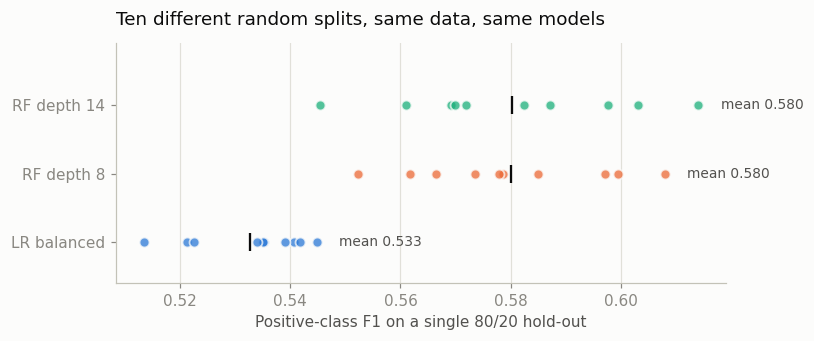

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
for i, (name, values) in enumerate(per_seed.items()):
    ax.scatter(values, [i] * len(values), s=42, color=SERIES[i], alpha=0.75,
               edgecolor='#fcfcfb', linewidth=1.2, zorder=3)
    ax.scatter([np.mean(values)], [i], s=150, marker='|', color=INK, zorder=4)
    ax.text(max(values) + 0.004, i, f'mean {np.mean(values):.3f}',
            va='center', fontsize=9, color='#52514e')
ax.set_yticks(range(len(per_seed)), list(per_seed))
ax.set_xlabel('Positive-class F1 on a single 80/20 hold-out')
ax.set_title('Ten different random splits, same data, same models', loc='left', pad=12)
ax.set_ylim(-0.6, len(per_seed) - 0.1)
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

**The finding.** The two random forests have essentially identical mean F1, yet on any
single split one of them "wins" — and which one wins depends on the seed. A student who
ran one split and reported a winner would be reporting noise.

The spread within a single model is also wide enough to swamp several of the genuine
improvements measured earlier. This is the argument for cross-validation or repeated
hold-out, made from evidence rather than assertion.

---
## Stage 6 — a more expressive model

Logistic regression assumes every effect is additive and monotonic. Two things in this
data are neither: sleep duration is harmful at both extremes, and coffee intake follows
a J-curve. There are also interactions — smoking and obesity together are worse than
the sum of their parts.

In [11]:
# Compared LIKE FOR LIKE: both class-weighted and both tuned. Comparing an unweighted
# tree against a weighted linear model would confound model family with imbalance
# handling and prove nothing about either.
weights = np.where(y_train == 1, (y_train == 0).sum() / (y_train == 1).sum(), 1.0)

gbm_search = GridSearchCV(HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                          {'max_leaf_nodes': [15, 31, 63], 'learning_rate': [0.05, 0.1],
                           'min_samples_leaf': [20, 50]},
                          scoring='f1', cv=5, n_jobs=-1).fit(X_train, y_train,
                                                             sample_weight=weights)
print(f'best gradient boosting: {gbm_search.best_params_}  (CV F1 {gbm_search.best_score_:.4f})')
best_gbm = gbm_search.best_estimator_
record('5 model', 'GBM balanced, tuned (trees)',
       metrics(y_val, best_gbm.predict(X_val)))

linear_f1 = [r for r in ladder if r['model'] == 'LR balanced, tuned'][0]['f1']
tree_f1 = [r for r in ladder if r['model'] == 'GBM balanced, tuned (trees)'][0]['f1']
print(f'\nlinear (tuned, weighted) F1 = {linear_f1:.4f}')
print(f'trees  (tuned, weighted) F1 = {tree_f1:.4f}')
print(f'gain from the model family  = {tree_f1 - linear_f1:+.4f}')

best gradient boosting: {'learning_rate': 0.1, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}  (CV F1 0.5908)
GBM balanced, tuned (trees)            acc=0.811  rec+=0.795  F1=0.6250  costA=  -27.9  costB=  +96.2

linear (tuned, weighted) F1 = 0.5547
trees  (tuned, weighted) F1 = 0.6250
gain from the model family  = +0.0703


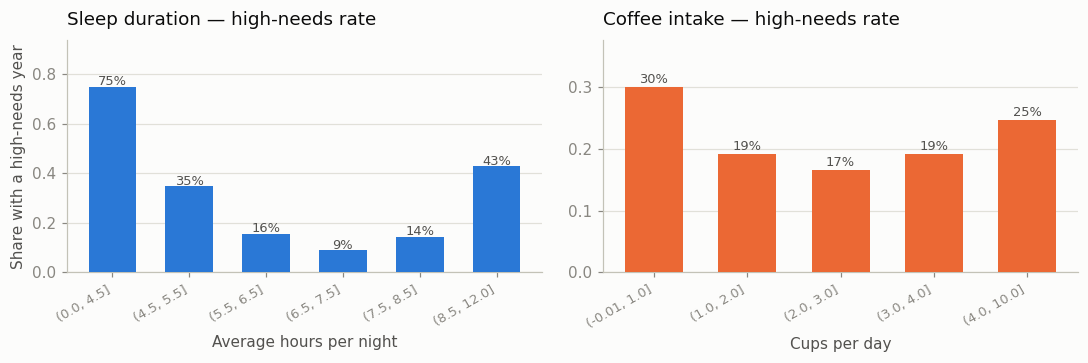

                            mean  size
Avg Sleep Hours Per Night             
(0.0, 4.5]                 0.749   410
(4.5, 5.5]                 0.348  1682
(5.5, 6.5]                 0.156  3874
(6.5, 7.5]                 0.090  2756
(7.5, 8.5]                 0.144  1096
(8.5, 12.0]                0.429   182


In [12]:
# Where does the gain come from? Compare the outcome rate across sleep duration --
# a linear model on raw hours cannot represent a curve with a minimum in the middle.
bins = pd.cut(dev_clean['Avg Sleep Hours Per Night'], [0, 4.5, 5.5, 6.5, 7.5, 8.5, 12])
rate_by_sleep = dev_clean.groupby(bins, observed=True)[TARGET].agg(['mean', 'size'])
cups = pd.cut(dev_clean['Daily Coffees'], [-0.01, 1, 2, 3, 4, 10])
rate_by_coffee = dev_clean.groupby(cups, observed=True)[TARGET].agg(['mean', 'size'])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, table, title, xlabel, colour in [
        (axes[0], rate_by_sleep, 'Sleep duration', 'Average hours per night', SERIES[0]),
        (axes[1], rate_by_coffee, 'Coffee intake', 'Cups per day', SERIES[1])]:
    labels = [str(i) for i in table.index]
    ax.bar(range(len(table)), table['mean'], color=colour, width=0.62, zorder=3)
    for i, v in enumerate(table['mean']):
        ax.text(i, v + 0.006, f'{v:.0%}', ha='center', fontsize=8.5, color='#52514e')
    ax.set_xticks(range(len(table)), labels, rotation=30, ha='right', fontsize=8.5)
    ax.set_title(f'{title} — high-needs rate', loc='left', pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylim(0, max(table['mean']) * 1.25)
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('Share with a high-needs year')
plt.tight_layout(); plt.show()

print(rate_by_sleep.round(3).to_string())

**The finding.** Both relationships are U-shaped: the lowest risk sits in the middle of
the range, and rises at both ends. A linear model given raw `Avg Sleep Hours Per Night`
must choose a single direction for the effect and therefore cannot fit either curve;
a tree splits the range and fits both arms.

This is where the gain over logistic regression comes from, and it is a much better
answer than "boosting is a stronger algorithm". A strong submission identifies the
structure and could, in principle, close most of the gap by engineering the right
features for the linear model instead.

---
## Stage 7 — cost, and who is paying

Every metric so far has treated a miss and a false alarm as equally regrettable. Neither
stakeholder does. Pricing the same confusion matrices under their two cost matrices is
what turns "which model is best?" into a question that can actually be answered — and it
needs nothing beyond the predictions already made.

In [13]:
candidates = {
    'LR balanced, tuned':   (lr_search, S_val),
    'RF balanced, tuned':   (best_rf,   X_val),
    'GBM balanced, tuned':  (best_gbm,  X_val),
    'LR unweighted':        (lr_scaled, S_val),
}

rows = []
for name, (model, features) in candidates.items():
    predictions = model.predict(features)
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_val, predictions),
        'precision': precision_score(y_val, predictions, zero_division=0),
        'recall': recall_score(y_val, predictions),
        'f1': f1_score(y_val, predictions),
        'agency (EUR/person)': cost_per_person(y_val, predictions, COST_PUBLIC_HEALTH),
        'employer (EUR/person)': cost_per_person(y_val, predictions, COST_EMPLOYER),
    })
comparison = pd.DataFrame(rows).set_index('model')
print(comparison.round(3).to_string())

print(f"\nmost accurate           : {comparison['accuracy'].idxmax()}")
print(f"best F1                 : {comparison['f1'].idxmax()}")
print(f"cheapest for the agency : {comparison['agency (EUR/person)'].idxmin()}")
print(f"cheapest for the employer: {comparison['employer (EUR/person)'].idxmin()}")

                     accuracy  precision  recall     f1  agency (EUR/person)  employer (EUR/person)
model                                                                                              
LR balanced, tuned      0.760      0.438   0.755  0.555               -2.845                 125.45
RF balanced, tuned      0.826      0.549   0.664  0.601               21.185                  97.51
GBM balanced, tuned     0.811      0.515   0.795  0.625              -27.945                  96.21
LR unweighted           0.830      0.635   0.326  0.431              153.795                 118.21

most accurate           : LR unweighted
best F1                 : GBM balanced, tuned
cheapest for the agency : GBM balanced, tuned
cheapest for the employer: GBM balanced, tuned


In [14]:
# Which pairs of models do the two stakeholders rank in OPPOSITE order?
names = list(comparison.index)
for i, one in enumerate(names):
    for other in names[i + 1:]:
        agency = one if comparison.loc[one, 'agency (EUR/person)'] < comparison.loc[other, 'agency (EUR/person)'] else other
        employer = one if comparison.loc[one, 'employer (EUR/person)'] < comparison.loc[other, 'employer (EUR/person)'] else other
        if agency != employer:
            print(f'DISAGREEMENT  {one}  vs  {other}')
            print(f'    agency prefers   {agency}')
            print(f'    employer prefers {employer}\n')

DISAGREEMENT  LR balanced, tuned  vs  RF balanced, tuned
    agency prefers   LR balanced, tuned
    employer prefers RF balanced, tuned

DISAGREEMENT  LR balanced, tuned  vs  LR unweighted
    agency prefers   LR balanced, tuned
    employer prefers LR unweighted



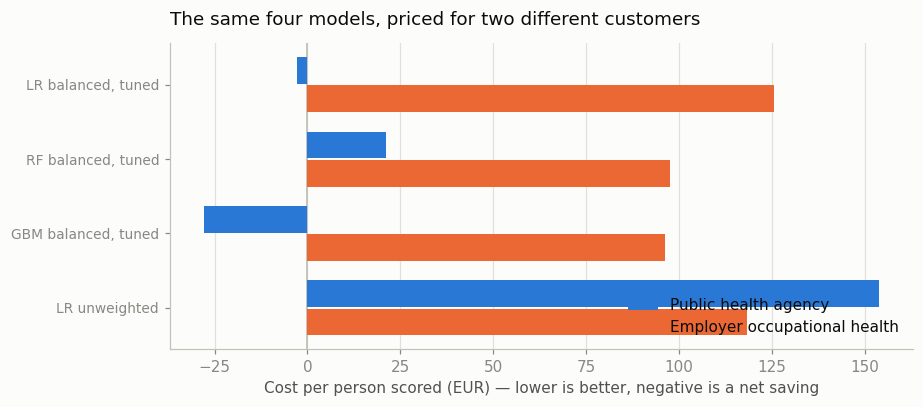

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
positions = np.arange(len(comparison))
ax.barh(positions - 0.19, comparison['agency (EUR/person)'], 0.36,
        color=SERIES[0], label='Public health agency', zorder=3)
ax.barh(positions + 0.19, comparison['employer (EUR/person)'], 0.36,
        color=SERIES[1], label='Employer occupational health', zorder=3)
ax.axvline(0, color='#c3c2b7', linewidth=1.2, zorder=2)
ax.set_yticks(positions, comparison.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Cost per person scored (EUR) — lower is better, negative is a net saving')
ax.set_title('The same four models, priced for two different customers', loc='left', pad=12)
ax.legend(loc='lower right')
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

**The findings.**

**The most accurate model is the worst model for both stakeholders.** The unweighted
logistic regression has the highest accuracy in the table and the highest cost to
everybody, because accuracy is dominated by the 80% of people who were never going to
have a high-needs year, and getting those right is worth nothing to either customer.

**The two stakeholders rank models in opposite orders.** The clearest case is the same
model twice — logistic regression with and without `class_weight='balanced'`. One flag
changes precision and recall in opposite directions, and that is enough to flip which
customer wants it. The agency wants the wide net because each miss costs it €1,450; the
employer would rather miss a few people than waste scarce programme places at €520 each.

**A model can win for both.** The tuned gradient boosting model is better on precision
*and* recall than the others here, so it dominates and both customers want it. That is a
legitimate outcome, not a failed experiment — it just means this particular comparison
does not force a trade-off. The interesting comparisons are the ones where neither model
dominates.

The recommendation to each stakeholder should be made in their terms, with their number.
"Model X is best" is not an answer to either of them.

---
## Stage 8 — the leakage trap

Every model since Stage 1 has excluded `SelfRatedHealth`. Here is what including it does.

In [16]:
X_leak, y_leak = encode(dev_clean, keep_self_rated_health=True)
XL_train, XL_val, yL_train, yL_val = train_test_split(
    X_leak, y_leak, test_size=0.2, stratify=y_leak, random_state=RANDOM_STATE)

gbm_leak = HistGradientBoostingClassifier(random_state=RANDOM_STATE).fit(XL_train, yL_train)
leaked = record('6 leakage', 'GBM including SelfRatedHealth',
                metrics(yL_val, gbm_leak.predict(XL_val)))

honest = [r for r in ladder if r['model'] == 'GBM balanced, tuned (trees)'][0]
print(f'\nF1       {honest["f1"]:.4f} -> {leaked["f1"]:.4f}   ({leaked["f1"]-honest["f1"]:+.4f})')
print(f'accuracy {honest["accuracy"]:.4f} -> {leaked["accuracy"]:.4f}   '
      f'({leaked["accuracy"]-honest["accuracy"]:+.4f})')
print(f'recall   {honest["recall"]:.4f} -> {leaked["recall"]:.4f}   '
      f'({leaked["recall"]-honest["recall"]:+.4f})')

GBM including SelfRatedHealth          acc=0.877  rec+=0.576  F1=0.6496  costA=  +46.7  costB=  +76.7

F1       0.6250 -> 0.6496   (+0.0246)
accuracy 0.8110 -> 0.8770   (+0.0660)
recall   0.7955 -> 0.5758   (-0.2197)


**The finding.** `SelfRatedHealth` delivers a free and genuinely large improvement. It is
also unusable, for two independent reasons.

**It would not exist at prediction time.** The deployment scenario is scoring people from
routinely held administrative and wearable data. `SelfRatedHealth` comes from the survey,
and the survey is not run on the population either stakeholder wants to screen. A model
that depends on it cannot be deployed at all — the column is simply absent.

**It is a measurement of the thing being predicted.** Self-rated health is well known to
predict later mortality and healthcare use *after* adjusting for every measured risk
factor, because respondents incorporate information no questionnaire captures. That is
exactly why it helps here, and exactly why using it is circular: it is a partial
observation of the outcome dressed up as a feature.

Worth stressing for marking: nothing about the modelling flags this. The pipeline runs,
cross-validation agrees, the test score improves. The only defence is reading the column
list and asking, of each feature, *would I have this, for this person, at the moment I
need to make the decision?*

---
## Stage 9 — overfitting: three different numbers for "how good is it?"

In [17]:
X_full, y_full = X, y
gbm_full = HistGradientBoostingClassifier(random_state=RANDOM_STATE).fit(X_full, y_full)

X_test, y_test = encode(test_raw)                       # encoding only -- never cleaned
X_test = X_test.reindex(columns=X_full.columns, fill_value=0)

resubstitution = accuracy_score(y_full, gbm_full.predict(X_full))
cv_scores = cross_val_score(HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                            X_full, y_full,
                            cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                            scoring='accuracy')
test_accuracy = accuracy_score(y_test, gbm_full.predict(X_test))
test_f1 = f1_score(y_test, gbm_full.predict(X_test))
cv_f1 = cross_val_score(HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                        X_full, y_full, cv=5, scoring='f1').mean()

print(f'training data (resubstitution)  accuracy {resubstitution:.4f}')
print(f'5-fold cross-validation         accuracy {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})')
print(f'held-out test set               accuracy {test_accuracy:.4f}')
print(f'\noptimism (train - CV):         {resubstitution - cv_scores.mean():+.4f}')
print(f'shift penalty (CV - test):       {cv_scores.mean() - test_accuracy:+.4f}')
print(f'\nF1:  CV {cv_f1:.4f}  vs  test {test_f1:.4f}   ({test_f1 - cv_f1:+.4f})')

training data (resubstitution)  accuracy 0.9245
5-fold cross-validation         accuracy 0.8511  (+/- 0.0021)
held-out test set               accuracy 0.8261

optimism (train - CV):         +0.0734
shift penalty (CV - test):       +0.0250

F1:  CV 0.5551  vs  test 0.6259   (+0.0708)


**The findings.**

**Scoring on the training data is meaningless.** Resubstitution accuracy overstates
cross-validated performance by around seven points, because the model has partly
memorised rows it was fitted on. This number should never appear in a report as an
estimate of performance.

**Cross-validation is honest about the development set but still optimistic about the
test set.** The remaining gap is not overfitting — cross-validation already controlled for
that. It is a property of the test set, and Stage 10 takes it apart.

**Accuracy falls, but the model has not stopped working.** More of the test population is
genuinely high-risk, so the majority-class baseline is harder to beat and a model that
identifies the same proportion of cases converts that into more errors in absolute terms.
Reporting accuracy alone makes the test set look like a model failure. Stage 10 shows it
is not.

---
## Stage 10 — is the test set representative?

The deepest layer, and where the highest marks are. The gap has three separable causes.

In [18]:
comparison = pd.DataFrame({
    'development': [len(dev_raw), dev_raw[TARGET].mean(),
                    dev_raw['Age'].where(dev_raw['Age'] <= 100).mean(),
                    (dev_raw['Country'] == 'UK').mean(),
                    (dev_raw['Smoking Status'] == 'Vaper').mean(),
                    dev_raw.duplicated().mean(),
                    (dev_raw['Age'] > 100).mean(), (dev_raw['BMI'] > 60).mean(),
                    dev_raw.isna().any(axis=1).mean()],
    'test': [len(test_raw), test_raw[TARGET].mean(),
             test_raw['Age'].where(test_raw['Age'] <= 100).mean(),
             (test_raw['Country'] == 'UK').mean(),
             (test_raw['Smoking Status'] == 'Vaper').mean(),
             test_raw.duplicated().mean(),
             (test_raw['Age'] > 100).mean(), (test_raw['BMI'] > 60).mean(),
             test_raw.isna().any(axis=1).mean()],
}, index=['rows', 'positive rate', 'mean age (valid)', 'share UK', 'share vaping',
          'duplicate rows', 'age anomalies', 'BMI anomalies', 'rows with missing data'])
print(comparison.round(4).to_string())

                        development       test
rows                     10040.0000  3060.0000
positive rate                0.1977     0.2562
mean age (valid)            40.6888    46.1588
share UK                     0.2498     0.4673
share vaping                 0.0267     0.0971
duplicate rows               0.0040     0.0196
age anomalies                0.0071     0.0330
BMI anomalies                0.0056     0.0167
rows with missing data       0.2617     0.0000


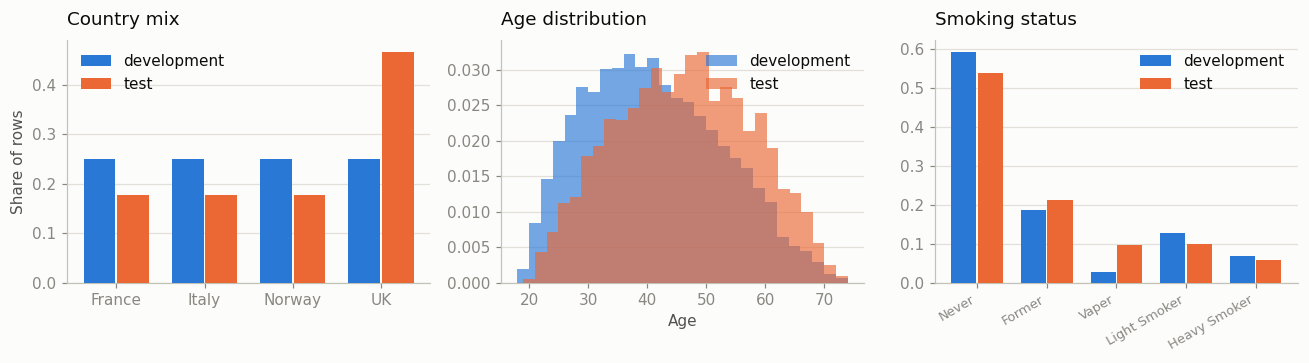

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

# Country mix
mix = pd.DataFrame({'development': dev_raw['Country'].value_counts(normalize=True),
                    'test': test_raw['Country'].value_counts(normalize=True)}).sort_index()
positions = np.arange(len(mix))
axes[0].bar(positions - 0.19, mix['development'], 0.36, color=SERIES[0],
            label='development', zorder=3)
axes[0].bar(positions + 0.19, mix['test'], 0.36, color=SERIES[1], label='test', zorder=3)
axes[0].set_xticks(positions, mix.index)
axes[0].set_title('Country mix', loc='left', pad=10)
axes[0].set_ylabel('Share of rows')
axes[0].legend()
axes[0].grid(axis='x', visible=False)

# Age
axes[1].hist(dev_raw['Age'].where(dev_raw['Age'] <= 100).dropna(), bins=28, density=True,
             color=SERIES[0], alpha=0.65, label='development', zorder=3)
axes[1].hist(test_raw['Age'].where(test_raw['Age'] <= 100).dropna(), bins=28, density=True,
             color=SERIES[1], alpha=0.65, label='test', zorder=3)
axes[1].set_title('Age distribution', loc='left', pad=10)
axes[1].set_xlabel('Age'); axes[1].legend()
axes[1].grid(axis='x', visible=False)

# Smoking status
smoke = pd.DataFrame({'development': dev_raw['Smoking Status'].value_counts(normalize=True),
                      'test': test_raw['Smoking Status'].value_counts(normalize=True)})
smoke = smoke.reindex(ORDINAL_SCALES['Smoking Status'])
positions = np.arange(len(smoke))
axes[2].bar(positions - 0.19, smoke['development'], 0.36, color=SERIES[0],
            label='development', zorder=3)
axes[2].bar(positions + 0.19, smoke['test'], 0.36, color=SERIES[1], label='test', zorder=3)
axes[2].set_xticks(positions, smoke.index, rotation=30, ha='right', fontsize=8.5)
axes[2].set_title('Smoking status', loc='left', pad=10)
axes[2].legend()
axes[2].grid(axis='x', visible=False)

plt.tight_layout(); plt.show()

### Layer 1 — the test set is measurably different

The UK share nearly doubles, the cohort is about five years older, and vaping is roughly
four times as common. None of this is subtle; all of it is findable with the same plots
CW1 asked for.

### Layer 2 — corrupted rows the model cannot possibly get right

In [20]:
corrupted = (test_raw['Age'] > 100) | (test_raw['BMI'] > 60)
predictions = gbm_full.predict(X_test)
correct = predictions == y_test

print(f'corrupted rows in the test set: {corrupted.sum()} ({corrupted.mean():.1%})')
print(f'accuracy on corrupted rows: {correct[corrupted.values].mean():.3f}')
print(f'accuracy on clean rows:     {correct[~corrupted.values].mean():.3f}')
print(f'\ntest accuracy as measured:       {correct.mean():.4f}')
print(f'test accuracy excluding corrupted: {correct[~corrupted.values].mean():.4f}')
print(f'  -> corrupted rows cost {correct.mean() - correct[~corrupted.values].mean():+.4f} accuracy')

duplicated = test_raw.duplicated(keep=False)
print(f'\nduplicate rows: {test_raw.duplicated().sum()}, '
      f'{(test_raw[test_raw.duplicated()]["Country"] == "UK").mean():.0%} of them UK')
print('   -> they are not a random sample, so they push the country mix further still')

corrupted rows in the test set: 149 (4.9%)
accuracy on corrupted rows: 0.758
accuracy on clean rows:     0.830

test accuracy as measured:       0.8261
test accuracy excluding corrupted: 0.8296
  -> corrupted rows cost -0.0035 accuracy

duplicate rows: 60, 83% of them UK
   -> they are not a random sample, so they push the country mix further still


The test set carries several times the development set's rate of data-entry anomalies,
and students may not repair them — the test set stands in for live data arriving as it
is. Those rows have labels that were determined by the person's true age and BMI, but
present corrupted values, so they are close to unpredictable by construction.

Quantifying this is the right move: it is worth roughly a point of accuracy, and it is
a *measurement* problem rather than a modelling one. The duplicates matter for a
different reason — they are drawn disproportionately from UK respondents, so they are
not merely redundant rows but a further distortion of the mix, and any duplicated row
the model gets wrong is counted against it twice.

### Layer 3 — the positive rate rose. Did risk actually change?

This is the finding that separates the top submissions. The positive rate is markedly
higher in the test set. The tempting conclusion is that the relationship between features
and outcome has changed — which would make the model obsolete. Checking is
straightforward: hold the *relationship* fixed and vary only the *mix*.

In [21]:
def stratified_expectation(dev_keys, test_keys):
    """Development-set outcome rates, reweighted to the test set's composition.

    If the test set's higher positive rate is purely a matter of WHO was recruited,
    this reproduces it. If it does not, the relationship itself has changed.
    """
    dev_rates = dev_raw.groupby(dev_keys, observed=True)[TARGET].mean()
    test_mix = test_raw.groupby(test_keys, observed=True).size() / len(test_raw)
    shared = dev_rates.index.intersection(test_mix.index)
    return float((dev_rates[shared] * test_mix[shared]).sum())

# Kept as standalone series rather than added as columns, so the raw frames stay
# exactly as loaded and can still be encoded downstream.
age_band = lambda d: pd.cut(d['Age'].where(d['Age'] <= 100), [0, 30, 45, 60, 100])
dev_band, test_band = age_band(dev_raw), age_band(test_raw)

print(f'development positive rate              {dev_raw[TARGET].mean():.3f}')
print(f'test positive rate                     {test_raw[TARGET].mean():.3f}\n')
print(f'expected from country mix alone        '
      f'{stratified_expectation(dev_raw["Country"], test_raw["Country"]):.3f}')
print(f'expected from age mix alone            '
      f'{stratified_expectation(dev_band, test_band):.3f}')
print(f'expected from country + age + smoking  '
      f'{stratified_expectation([dev_raw["Country"], dev_band, dev_raw["Smoking Status"]], [test_raw["Country"], test_band, test_raw["Smoking Status"]]):.3f}')

print('\npositive rate within each country:')
print(pd.DataFrame({'development': dev_raw.groupby('Country')[TARGET].mean(),
                    'test': test_raw.groupby('Country')[TARGET].mean()}).round(3).to_string())
print('\npositive rate within each age band:')
print(pd.DataFrame({'development': dev_raw.groupby(dev_band, observed=True)[TARGET].mean(),
                    'test': test_raw.groupby(test_band, observed=True)[TARGET].mean()}).round(3).to_string())

development positive rate              0.198
test positive rate                     0.256

expected from country mix alone        0.211
expected from age mix alone            0.210
expected from country + age + smoking  0.232

positive rate within each country:
         development   test
Country                    
France         0.239  0.279
Italy          0.155  0.191
Norway         0.155  0.210
UK             0.242  0.290

positive rate within each age band:
           development   test
Age                          
(0, 30]          0.158  0.175
(30, 45]         0.182  0.214
(45, 60]         0.229  0.276
(60, 100]        0.333  0.385


In [22]:
# The decisive test, without needing probabilities: if the RELATIONSHIP had changed,
# the model would get worse at identifying cases WITHIN a subgroup. If only the mix
# changed, per-subgroup performance holds and only the overall numbers move.
# Compared against the held-out validation split, not the training data.
val_predictions = best_gbm.predict(X_val)
test_predictions = best_gbm.predict(X_test)
validation_rows = dev_clean.loc[X_val.index]

print('overall, held-out validation split vs test set:')
print(f'  validation  recall={recall_score(y_val, val_predictions):.3f}  '
      f'precision={precision_score(y_val, val_predictions):.3f}  '
      f'accuracy={accuracy_score(y_val, val_predictions):.3f}')
print(f'  test        recall={recall_score(y_test, test_predictions):.3f}  '
      f'precision={precision_score(y_test, test_predictions):.3f}  '
      f'accuracy={accuracy_score(y_test, test_predictions):.3f}')

# Precision within each country: is a positive call as trustworthy on test as it was
# in validation?
per_country = []
for country in sorted(test_raw['Country'].unique()):
    in_validation = (validation_rows['Country'].values == country)
    in_test = (test_raw['Country'].values == country)
    per_country.append({
        'country': country,
        'validation precision': precision_score(y_val[in_validation],
                                                val_predictions[in_validation], zero_division=0),
        'test precision': precision_score(y_test[in_test],
                                          test_predictions[in_test], zero_division=0),
        'validation recall': recall_score(y_val[in_validation], val_predictions[in_validation]),
        'test recall': recall_score(y_test[in_test], test_predictions[in_test]),
    })
per_country = pd.DataFrame(per_country).set_index('country')
print('\nwithin each country:')
print(per_country.round(3).to_string())
gap = (per_country['validation precision'] - per_country['test precision']).abs().mean()
print(f'\nmean absolute precision gap across countries: {gap:.3f}')

overall, held-out validation split vs test set:
  validation  recall=0.795  precision=0.515  accuracy=0.811
  test        recall=0.837  precision=0.543  accuracy=0.778

within each country:
         validation precision  test precision  validation recall  test recall
country                                                                      
France                  0.527           0.565              0.870        0.927
Italy                   0.464           0.483              0.797        0.798
Norway                  0.617           0.566              0.860        0.825
UK                      0.464           0.546              0.675        0.817

mean absolute precision gap across countries: 0.047


**The finding — and it is the important one.** The rise is **compositional**, not a change
in underlying risk.

Reweighting the development set's own within-group rates to the test set's mix of country,
age band and smoking status recovers most of the gap: from 0.198 up to about 0.232 against
an observed 0.256. Coarse stratification on three variables does not close it completely,
and should not be expected to — the cohorts differ on more than three variables and the
bands are wide.

The decisive evidence is what happens **inside** each subgroup. Precision barely moves —
a mean absolute gap of about five percentage points across the four countries — so a
positive prediction on the test set is about as trustworthy as one made on the validation
split. Recall holds or improves in three countries out of four, and rises overall. A model whose learned relationship had gone stale would get **worse** at
identifying cases within a country, not better.

Put the two observations together and the picture is unambiguous: accuracy falls, while
precision and recall hold or improve. That is the signature of a population with more
positive cases in it, not of a model that has stopped working. Accuracy is the metric most
sensitive to how common the positive class is, which is exactly why it is the one that
drops.

So what the model learned is intact; what changed is **who was recruited**. This is
covariate shift, not concept drift, and the distinction has real consequences: the model
does not need retraining, but the **costs each stakeholder should expect do need
recalculating**, because they were estimated against a population with a different mix.

A submission that reports "the test set has a higher positive rate, so the data has
drifted and the model is stale" has stopped one step too early. The evidence says
otherwise.

---
## Stage 11 — the benchmark

In [23]:
results = pd.DataFrame(ladder)[['stage', 'model', 'accuracy', 'precision', 'recall',
                                'f1', 'cost_agency', 'cost_employer']]
print(results.round(4).to_string(index=False))

      stage                            model  accuracy  precision  recall     f1  cost_agency  cost_employer
  0 starter     LogisticRegression() default    0.7969     0.2667  0.0137 0.0260     283.1077       156.2762
  0 starter   KNeighborsClassifier() default    0.7657     0.1954  0.0580 0.0895     271.1984       169.4787
  1 cleaned LR, repaired + imputed, unscaled    0.8020     0.0000  0.0000 0.0000     287.1000       154.4400
  2 scaling                KNN k=5, unscaled    0.7755     0.2523  0.0682 0.1074     265.0050       163.6300
  2 scaling                  KNN k=5, scaled    0.8280     0.6444  0.2929 0.4028     167.0000       121.2000
  2 scaling                       LR, scaled    0.8295     0.6355  0.3258 0.4307     153.7950       118.2100
3 imbalance          LR scaled, no weighting    0.8295     0.6355  0.3258 0.4307     153.7950       118.2100
3 imbalance         LR scaled + class_weight    0.7600     0.4384  0.7551 0.5547      -2.8450       125.4500
3 imbalance        

In [24]:
# Every model refitted on the FULL development set, then scored once on the held-out
# test set. Plain .predict() throughout.
from sklearn.base import clone

benchmark = []

# 1. The starter pipeline, exactly as handed out: naive cleaning, SelfRatedHealth
#    left in as a feature, no scaling, defaults.
starter_test_X, starter_test_y = encode(test_raw, keep_self_rated_health=True)
starter_test_X = starter_test_X.reindex(columns=X_naive.columns, fill_value=0)
starter = LogisticRegression().fit(X_naive, y_naive)
benchmark.append(('Starter LR (unscaled, defaults)',
                  starter_test_y, starter.predict(starter_test_X)))

# 2-4. The improved pipeline: careful cleaning, SelfRatedHealth excluded.
final_test_X, final_test_y = encode(test_raw)
final_test_X = final_test_X.reindex(columns=X.columns, fill_value=0)

scaler_final = StandardScaler().fit(X)
lr_final = clone(lr_search.best_estimator_).fit(scaler_final.transform(X), y)
benchmark.append(('LR balanced, tuned',
                  final_test_y, lr_final.predict(scaler_final.transform(final_test_X))))

rf_final = clone(best_rf).fit(X, y)
benchmark.append(('RF balanced, tuned', final_test_y, rf_final.predict(final_test_X)))

full_weights = np.where(y == 1, (y == 0).sum() / (y == 1).sum(), 1.0)
gbm_final = clone(best_gbm).fit(X, y, sample_weight=full_weights)
benchmark.append(('GBM balanced, tuned', final_test_y, gbm_final.predict(final_test_X)))

print('Held-out test set -- the benchmark everyone is compared on\n')
summary = pd.DataFrame([{
    'model': name,
    'accuracy': accuracy_score(truth, predicted),
    'precision': precision_score(truth, predicted, zero_division=0),
    'recall': recall_score(truth, predicted),
    'f1': f1_score(truth, predicted),
    'agency EUR/person': cost_per_person(truth, predicted, COST_PUBLIC_HEALTH),
    'employer EUR/person': cost_per_person(truth, predicted, COST_EMPLOYER),
} for name, truth, predicted in benchmark]).set_index('model')
print(summary.round(3).to_string())

Held-out test set -- the benchmark everyone is compared on

                                 accuracy  precision  recall     f1  agency EUR/person  employer EUR/person
model                                                                                                      
Starter LR (unscaled, defaults)     0.762      0.571   0.287  0.382            221.886              165.327
LR balanced, tuned                  0.673      0.426   0.787  0.552            -17.042              167.993
RF balanced, tuned                  0.798      0.581   0.751  0.656            -21.245              106.359
GBM balanced, tuned                 0.771      0.534   0.841  0.653            -62.003              112.346


### Where the ladder ends up

Reading down the table: the starter pipeline finds almost nobody and hands both customers
close to the worst outcome available to them. Careful cleaning, scaling, class weighting,
tuning and a model that can represent non-monotonic effects turn that into a model that
finds most of the high-needs cases and produces a **net saving** for the public health
agency.

Note what did *not* help: tuning logistic regression's regularisation, and scaling for
logistic regression specifically. Reporting the changes that made no difference is part of
the work, not an admission of failure.

**Benchmark for the cohort.** The tuned gradient boosting model's held-out figures above
are the numbers to beat. Beating them on F1 is one contest; beating them on cost, for a
named stakeholder, is the one that actually matters — and the two can be won by different
models, which is the whole point of Stage 7.